In [3]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt

In [4]:
@jit(nopython=True)
def u_exact(x, t, eps = 0.1):
    alphas = np.array([1, 4, 16], dtype=np.float64)
    u = np.zeros_like(x, dtype = np.float64)

    for alpha in alphas:
        u += np.exp(-eps * alpha**2 * t) * np.cos(alpha * x)

    return u

@jit(nopython=True)
def gL(t):
    return u_exact(np.array([-1.0], dtype=np.float64), t)[0]

@jit(nopython=True)
def gR(t):
    return u_exact(np.array([1.0], dtype=np.float64), t)[0]

@jit(nopython=True)
def eta(x,eps = 0.1):
    return u_exact(x, 0.0, eps)

In [5]:
@jit
def FTCS(eps, T, Nx, left_bc, right_bc, initial_cond):
    xmin, xmax = -1, 1
    h = (xmax - xmin) / Nx
    x = np.linspace(xmin, xmax, Nx + 1)

    # stability
    k = 0.9 * h**2 / (2 * eps)
    Nt = int(T / k)
    k = T / Nt
    r = eps * k / h**2
    t = []

    u = np.zeros((Nt + 1, Nx + 1))

    # initial condition from exact solution
    u[0, :] = initial_cond(x, eps)

    for n in range(Nt):
        ti = n * k
        t.append(ti)

        # boundary conditions from exact solution
        u[n, 0] = left_bc(ti)
        u[n, -1] = right_bc(ti)

        for i in range(1, Nx):
            u[n+1, i] = (
                u[n, i]
                + r * (u[n, i+1] - 2*u[n, i] + u[n, i-1])
            )

        # enforce BC at next time level too
        u[n+1, 0] = left_bc(ti + k)
        u[n+1, -1] = right_bc(ti + k)

    t.append(T)
    return u, k, h, x, np.array(t)

In [12]:
Nx_values = [25, 50, 100, 200, 400, 800]

pick_out_sol = {
    'which': 800,
}

dx_errors = []
dx_values = []

eps = 0.1
T = 1.0

for Nx in Nx_values:

    u, dt, dx, x, t = FTCS(eps, T, Nx, gL, gR, eta)
    if Nx == pick_out_sol['which']:
        pick_out_sol['u'] = u
        pick_out_sol['x'] = x
        pick_out_sol['t'] = t

    # exact solution at final time
    u_ex = u_exact(x, T, eps)

    # max norm error
    error = np.max(np.abs(u[-1, :] - u_ex))

    dx_errors.append(error)
    dx_values.append(dx)

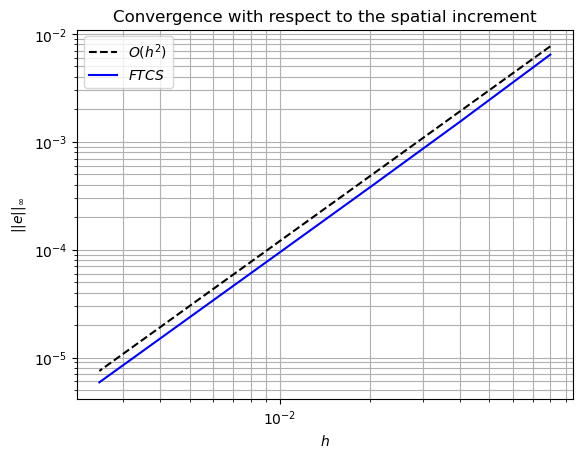

array([ 2.00035818, -0.05764964])

In [7]:
plt.loglog(dx_values,1.2*np.array(dx_values)**2, 'k--', label=r"$O(h^2)$")
plt.loglog(dx_values,dx_errors,color="blue", label=r"$FTCS$")
plt.title("Convergence with respect to the spatial increment")
plt.xlabel(r'$h$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dx_values[4:]),np.log(dx_errors[4:]),1)

In [13]:
x, t, u = pick_out_sol['x'], pick_out_sol['t'], pick_out_sol['u']
print(x.shape, t.shape, u.shape)

(801,) (35556,) (35556, 801)


In [ ]:
U_exact = np.array([u_exact(x, ti, eps) for ti in t])

fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[1, :])

im0 = ax0.pcolormesh(x, t, u, cmap='seismic', shading='auto')
cbar0 = fig.colorbar(im0, ax=ax0, orientation='vertical', pad=0.12)
cbar0.ax.set_xlabel('u(x, t)', labelpad=10)
ax0.set_xlabel('x')
ax0.set_ylabel('t')
ax0.set_title('FTCS Solution')
ax0.grid(True)

im1 = ax1.pcolormesh(x, t, U_exact, cmap='seismic', shading='auto')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='vertical', pad=0.12)
cbar1.ax.set_xlabel('u(x, t)', labelpad=10)
ax1.set_xlabel('x')
ax1.set_title('Exact Solution')
ax1.grid(True)

im2 = ax2.pcolormesh(x, t, u - U_exact, cmap='seismic', shading='auto')
cbar2 = fig.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02)
cbar2.set_label('Error (u - u_exact)')
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('Difference between FTCS and Exact Solution')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
Nt_values = [50, 100, 200, 400, 800, 1600]

dt_errors = []
dt_values = []

eps = 0.1
T = 1.0
xmin, xmax = -1, 1
L = xmax - xmin

r0 = 0.4  # safety factor (< 0.5)

pick_out_sol['which'] = 100

for Nt in Nt_values:

    # time step
    dt = T / Nt

    # stable spatial step from diffusion CFL
    dx = np.sqrt(eps * dt / r0)

    # corresponding grid size
    Nx = int(L / dx)

    # run FTCS
    u, dt_used, dx_used, x, t = FTCS(eps, T, Nx, gL, gR, eta)

    if pick_out_sol['which'] == Nt:
        print(Nt)
        pick_out_sol['u'] = u
        pick_out_sol['x'] = x
        pick_out_sol['t'] = t

    # exact solution
    u_ex = u_exact(x, T, eps)

    # error
    error = np.max(np.abs(u[-1, :] - u_ex))

    dt_errors.append(error)
    dt_values.append(dt)

x,t,u = pick_out_sol['x'], pick_out_sol['t'], pick_out_sol['u']
print(x.shape, t.shape, u.shape)

100
(41,) (89,) (89, 41)


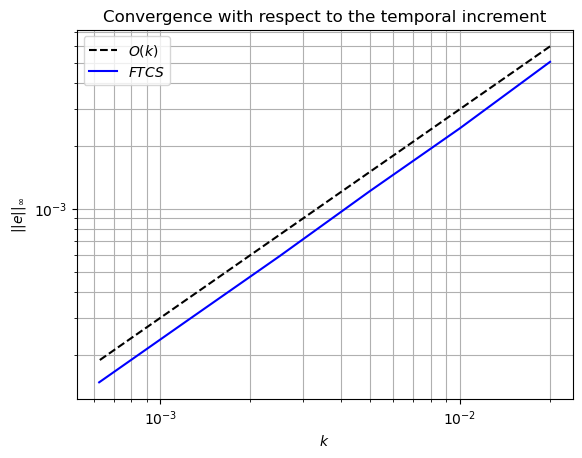

array([ 1.00366838, -1.41752269])

In [10]:
plt.loglog(dt_values,0.3*np.array(dt_values), 'k--', label=r"$O(k)$")
plt.loglog(dt_values,dt_errors,color="blue", label=r"$FTCS$")
plt.title("Convergence with respect to the temporal increment")
plt.xlabel(r'$k$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dt_values[3:]),np.log(dt_errors[3:]),1)